In [2]:
import pandas as pd


In [3]:
df = pd.read_csv('Mall_Customers.csv')
df.head()




,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Female,21,15,81
2,3,Male,20,16,6
3,4,Female,23,16,77
4,5,Male,31,17,40


In [4]:
#selecting features(numbers wale)

X = df[['Annual Income (k$)', 'Spending Score (1-100)','Age']].copy()

#selecting  categorical features
X['Gender'] = df['Gender'].map({'Male':0,'Female':1})

X.head()

,Annual Income (k$),Spending Score (1-100),Age,Gender
0,15,39,19,0
1,15,81,21,1
2,16,6,20,0
3,16,77,23,1
4,17,40,31,0


In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()   
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5]) 


[[-1.58525817 -0.35902766 -0.99444379 -1.        ]
 [-1.58525817  0.90282689 -0.85868355  1.        ]
 [-1.21225625 -1.35048481 -0.92656367 -1.        ]
 [-1.21225625  0.78265027 -0.7229233   1.        ]
 [-0.83925433 -0.32898351 -0.17988232 -1.        ]]


In [6]:
from sklearn.cluster import KMeans

#pick number of clusters

k=4
km = KMeans(n_clusters=k,random_state=42,n_init=10)
labels = km.fit_predict(X_scaled)

df['Cluster'] = labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,3
1,2,Female,21,15,81,1
2,3,Male,20,16,6,3
3,4,Female,23,16,77,1
4,5,Male,31,17,40,3


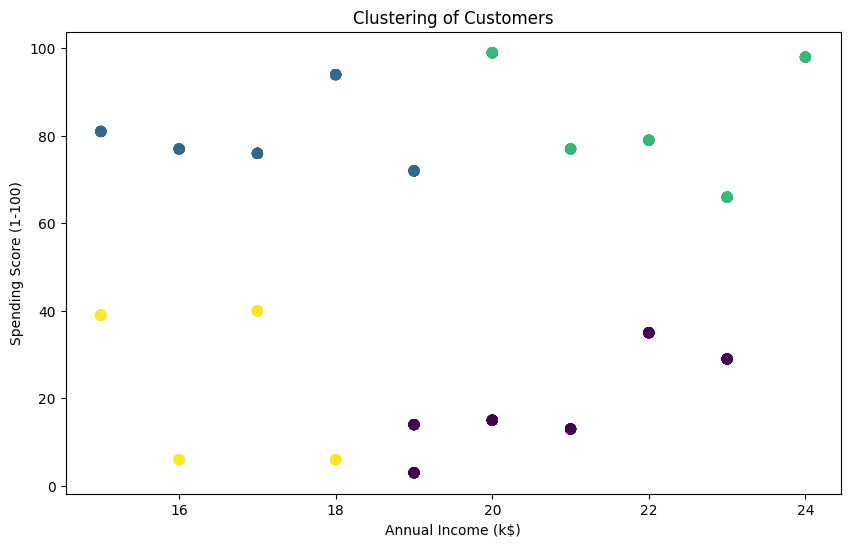

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'],c=df['Cluster'],cmap='viridis',s=50)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Clustering of Customers')
plt.show()

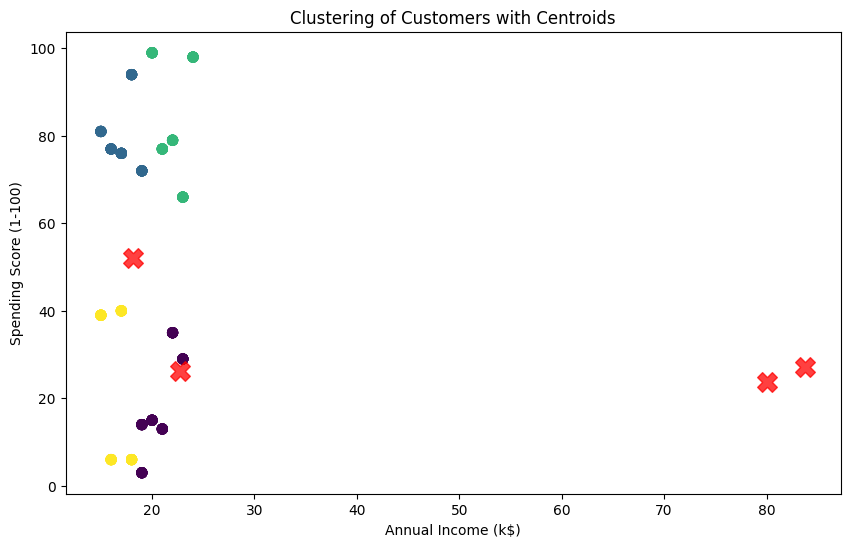

In [8]:
centers = km.cluster_centers_

#reverse scaling back to original scale
centers_unscaled = scaler.inverse_transform(centers)


plt.figure(figsize=(10,6))
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'],c=df['Cluster'],cmap='viridis',s=50)
plt.scatter(centers_unscaled[:,1]  ,centers_unscaled[:,2],c='red',s=200,alpha=0.75,marker='X')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Clustering of Customers with Centroids') 
plt.show()

In [11]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,104.0,52.166667,20.666667,18.166667
1,96.0,23.800000,17.000000,80.000000
2,106.0,27.200000,22.000000,83.800000
3,94.0,26.250000,16.500000,22.750000


In [12]:

# cluster 0: older, mid-low income, low spending score
# cluster 1: young adults, low income, high spending score 
# cluster 2: young adults, mid-high income, high spending score
# cluster 3: young adults, low income, low spending score

In [ ]:

# who spends the most: (cluster 1 & 2)
# who spends the least: (cluster 0 & 3)


# which groups are worth targeting: (cluster 1 & 2)